# Build network based on kinase-phosphosite interactions

This notebook provides the code to create a network based on kinase-substrate interactions and the annotated effect of phosphorylation (based on PhosphositePlus) on the activity of the substrate.

In [1]:
%%time
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
from neko.inputs import Universe, phosphosite
from neko._annotations.gene_ontology import Ontology
import omnipath as op
import pandas as pd

CPU times: total: 4.61 s
Wall time: 9.23 s


## 1. Specify kinase-substrate interaction file and phosphosite effect annotation

In this example, both files we utilize are from PhosphositePlus.

In [2]:
kinase_int_file = ("../neko/_data/Kinase_Substrate_Dataset")
phospho_effect_file = ("../neko/_data/Regulatory_sites")

## 2. Add interactions as a resource database

The *_process_psp_interactions_* function parses the provided files to create an interaction database in the Omnipath format.

In [2]:
resources = phosphosite()

In [3]:
resources.interactions

,source,target,is_directed,consensus_direction,consensus_stimulation,consensus_inhibition,is_stimulation,is_inhibition,curation_effort,references,sources,form_complex
0,EIF2AK1,EIF2S1_S52,True,False,False,False,True,True,NaN,NaN,NaN,False
1,PRKCD,HDAC5_S259,True,False,False,False,True,True,NaN,NaN,NaN,False
2,PRKCD,PTPRA_S204,True,False,False,False,True,False,NaN,NaN,NaN,False
3,PRKCD,BCL2_S70,True,False,False,False,False,True,NaN,NaN,NaN,False
4,PRKCD,SLC9A1_S648,True,False,False,False,False,True,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...
7399,MAP3K20_T162,MAP3K20,True,False,False,False,True,False,False,False,False,False
7400,MAP3K20_S165,MAP3K20,True,False,False,False,True,False,False,False,False,False
7401,MAP3K20_T161,MAP3K20,True,False,False,False,True,False,False,False,False,False
7402,MAP3K4_T1494,MAP3K4,True,False,False,False,True,False,False,False,False,False


## 3. Define a set of phosphosites we are interested in

In [3]:
genes = ['AKT1S1_T246', 'GSK3B_S9', 'AKT1_S473', 'HSPB1_S78', 'HSPB1_S82', 'MAPK14_T180', 'MAPK14_Y182', 'MAP2K1_S218', 'MAP2K1_S222', 'RPS6KA1_S380', 'MTOR_S2448', 'JUN_S63', 'MAPK3_T202', 'MAPK3_Y204']

## 4. Build network

In [4]:
%%time
new_net1 = Network(genes, resources=resources.interactions)

CPU times: total: 453 ms
Wall time: 451 ms


<div class="alert alert-info">

**Note**
    
Neko is based on UniProt IDs. It is still possible to use databases with other IDs, but an error message will appear during the translation progress, as in the example below.  

</div>  

In [10]:
%%time
new_net1.complete_connection(maxlen=4, algorithm= 'bfs',only_signed=True, connect_with_bias=True)

CPU times: total: 8.8 s
Wall time: 8.81 s


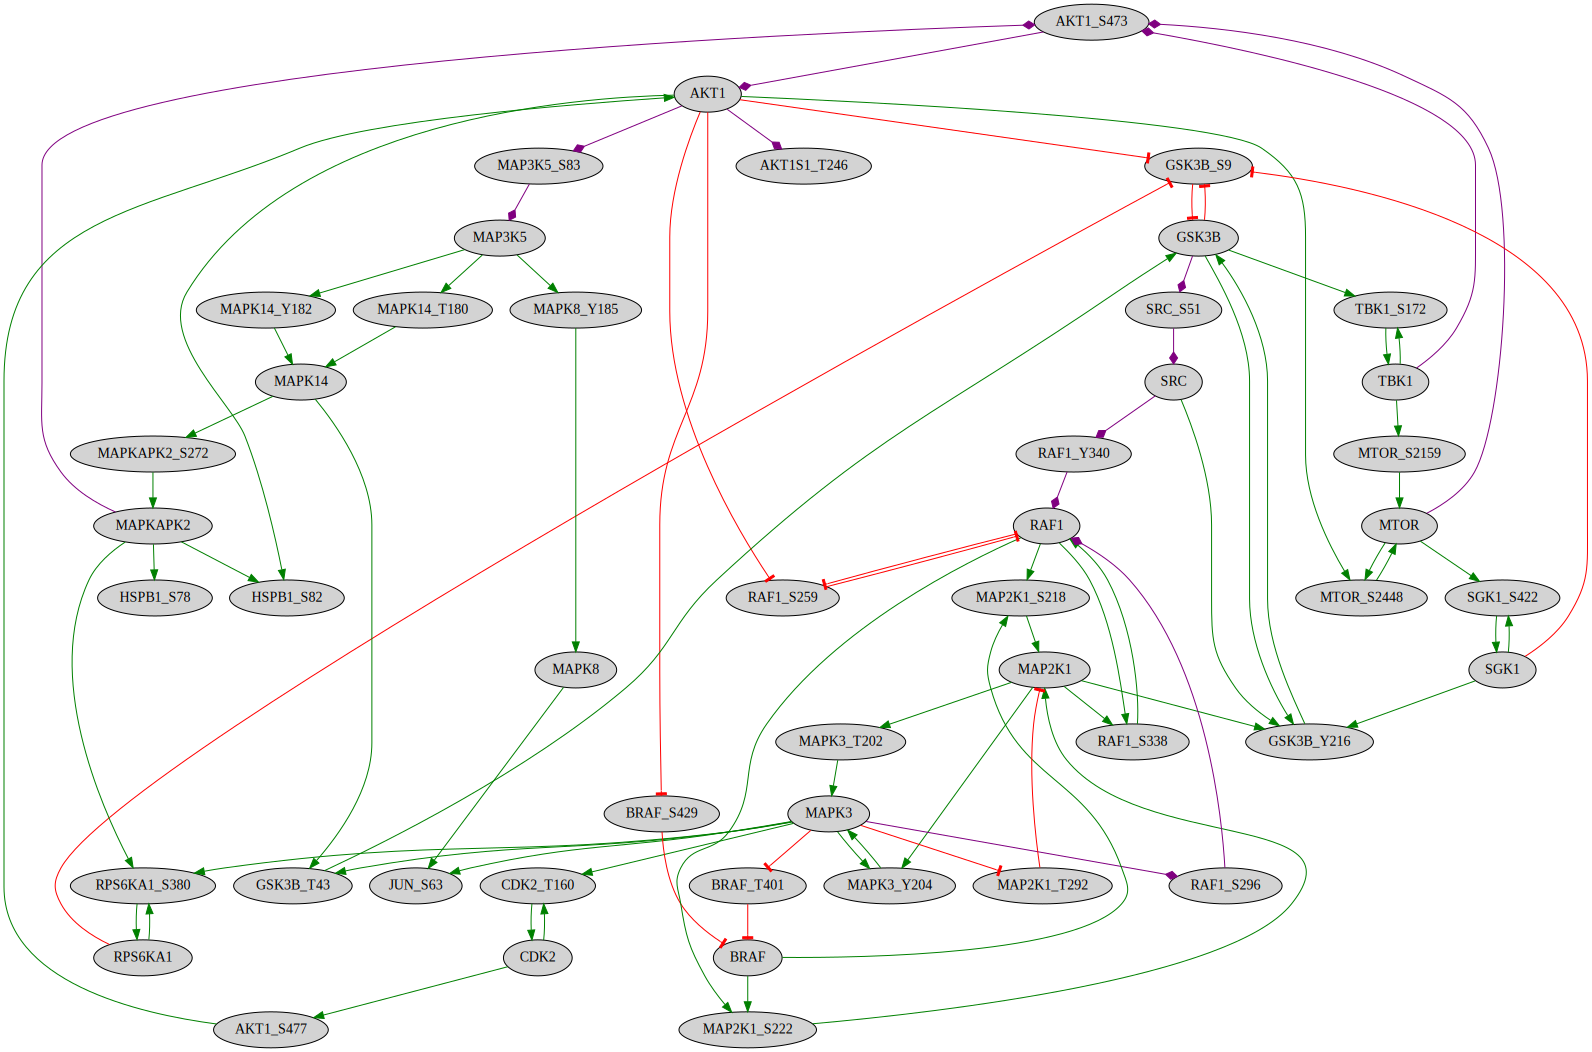

In [11]:
visualizer1 = NetworkVisualizer(new_net1, color_by='effect')
visualizer1.render()